In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from utils.data import DataManager
from utils.tools.config import (
    BENCHMARKS, 
    RISK_ANALYSIS,
    ANALYSIS_START_DATE,
    ANALYSIS_END_DATE
)

from utils.analysis.risk_metrics import (
    VarEsAnalyzer, VarEsReporter,
    RatioAnalyzer, RatioReporter,
    DistributionAnalyzer, DistributionReporter,
    BenchmarkAnalyzer, BenchmarkReporter,
    DrawdownAnalyzer, DrawdownReporter,
    CorrelationAnalyzer, CorrelationReporter
)

from utils.visualizations import (
    DrawdownVisualizer, 
    DistributionVisualizer, 
    VarEsVisualizer, 
    RatioVisualizer, 
    BenchmarkVisualizer
)

from utils.analysis.risk_metrics.components import calculate_portfolio_returns

In [ ]:
# 📊 CONFIGURACIÓN DEL ANÁLISIS
# Las fechas vienen de config.py (ANALYSIS_DATES)
# Personaliza aquí solo si necesitas valores diferentes

# Portfolio a analizar
TICKERS = ["META", "AAPL", "GOOGL", "NVDA", "MSFT"] 
BENCHMARK_NAME = "SP500"

# (Opcional) Fechas personalizadas - Deja vacío para usar config.py
USE_CUSTOM_DATES = False
START_DATE = ""  # Ej: "2020-01-01"
END_DATE = ""    # Ej: "2024-12-31"

# Pesos del portfolio (igual peso por defecto)
WEIGHTS = np.ones(len(TICKERS)) / len(TICKERS)

# Constantes desde config
RISK_FREE_RATE = RISK_ANALYSIS['risk_free_rate']
ANNUAL_FACTOR = RISK_ANALYSIS['annual_factor']
DEFAULT_CONFIDENCE = RISK_ANALYSIS['default_confidence_level']
CONFIDENCE_LEVELS = RISK_ANALYSIS['default_confidence_levels']
ROLLING_WINDOW = RISK_ANALYSIS['rolling']['default_window']
MC_SIMULATIONS = RISK_ANALYSIS['monte_carlo']['n_simulations']
MC_SEED = RISK_ANALYSIS['monte_carlo']['seed']

# Resolver fechas
if USE_CUSTOM_DATES and START_DATE and END_DATE:
    final_start, final_end = START_DATE, END_DATE
    print(f"📅 Usando fechas personalizadas: {final_start} → {final_end}")
else:
    final_start, final_end = ANALYSIS_START_DATE, ANALYSIS_END_DATE
    print(f"📅 Usando fechas de config.py: {final_start} → {final_end}")

print(f"\n📊 Portfolio: {len(TICKERS)} activos")
print(f"📈 Benchmark: {BENCHMARK_NAME}")
print(f"⚖️  Pesos: Igual peso ({1/len(TICKERS):.1%} cada uno)")

In [ ]:
# 📥 DESCARGA DE DATOS
data_manager = DataManager()

print("🔄 Descargando datos...")
assets_prices, benchmark_prices = data_manager.download_portfolio_with_benchmark(
    tickers=TICKERS,
    benchmark_name=BENCHMARK_NAME,
    start_date=final_start,
    end_date=final_end
)

# Calcular retornos
returns = assets_prices.pct_change().dropna()
benchmark_returns = benchmark_prices.pct_change().dropna()

print(f"\n✅ Datos descargados:")
print(f"   Período: {assets_prices.index[0].date()} → {assets_prices.index[-1].date()}")
print(f"   Días: {len(assets_prices)}")
print(f"   Activos: {list(returns.columns)}")

In [ ]:
# 🔧 INICIALIZACIÓN DE ANALYZERS

# Analyzers
var_es_analyzer = VarEsAnalyzer(annual_factor=ANNUAL_FACTOR)
ratio_analyzer = RatioAnalyzer(annual_factor=ANNUAL_FACTOR, risk_free_rate=RISK_FREE_RATE)
dist_analyzer = DistributionAnalyzer(annual_factor=ANNUAL_FACTOR)
benchmark_analyzer = BenchmarkAnalyzer(annual_factor=ANNUAL_FACTOR)
drawdown_analyzer = DrawdownAnalyzer()
corr_analyzer = CorrelationAnalyzer()

# Reporters
var_es_reporter = VarEsReporter(var_es_analyzer)
ratio_reporter = RatioReporter(ratio_analyzer)
dist_reporter = DistributionReporter(dist_analyzer)
benchmark_reporter = BenchmarkReporter(benchmark_analyzer)
drawdown_reporter = DrawdownReporter(drawdown_analyzer)
corr_reporter = CorrelationReporter(corr_analyzer)

# Visualizers
drawdown_viz = DrawdownVisualizer(drawdown_analyzer)
dist_viz = DistributionVisualizer(dist_analyzer)
var_es_viz = VarEsVisualizer(var_es_analyzer)
ratio_viz = RatioVisualizer(ratio_analyzer)
benchmark_viz = BenchmarkVisualizer(benchmark_analyzer)

print("✅ Todos los analyzers, reporters y visualizers inicializados")

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed

Descargando portafolio completo...
Período: 2020-01-01 → 2024-12-31
Período: 2020-01-01 → 2024-12-31
Portafolio descargado: 5 activos + benchmark


In [ ]:
# 📊 ANÁLISIS VAR Y EXPECTED SHORTFALL
portfolio_returns = calculate_portfolio_returns(returns, WEIGHTS)

print("🔍 Calculando VaR y Expected Shortfall...\n")

var_es_result = var_es_analyzer.analyze_var_es(
    portfolio_returns,
    confidence_levels=CONFIDENCE_LEVELS,
    n_simulations=MC_SIMULATIONS,
    seed=MC_SEED
)

# Mostrar resultados
var_es_reporter.print_var_es_summary(var_es_result, confidence_level=DEFAULT_CONFIDENCE)

# Visualizar
fig = var_es_viz.plot_var_es(var_es_result, confidence_level=DEFAULT_CONFIDENCE)
plt.show()

In [ ]:
# 📈 ANÁLISIS DE RATIOS DE RENDIMIENTO
print("🔍 Calculando ratios de rendimiento...\n")

ratios = ratio_analyzer.analyze_ratios(portfolio_returns, benchmark_returns)

# Mostrar resultados
ratio_reporter.print_ratios_summary(ratios)

# Visualizar
fig = ratio_viz.plot_ratios_comparison(ratios)
plt.show()

                    RESUMEN RÁPIDO DEL PORTAFOLIO                     
  Retorno anual:              37.90%
  Volatilidad anual:          32.46%
  Sharpe Ratio:               1.029
  Retorno/Riesgo:             1.168


               VaR y ES - Comparación de Métodos (95%)                
             ANÁLISIS VaR y ES (Nivel de confianza: 95%)              
COMPARACIÓN DE MÉTODOS
Método          VaR Diario      VaR Anual       ES Diario       ES Anual       
Historical        -3.32%       -52.74%        -4.65%       -73.79%
Parametric        -3.21%       -50.98%        -4.07%       -64.53%
Monte_carlo       -3.27%       -51.93%        -4.13%       -65.49%
INTERPRETACIÓN
VaR promedio diario:     -3.27%
ES promedio diario:      -4.28%
Pérdida máxima esperada: -4.28% en un día adverso
  Nivel de riesgo:         Moderado


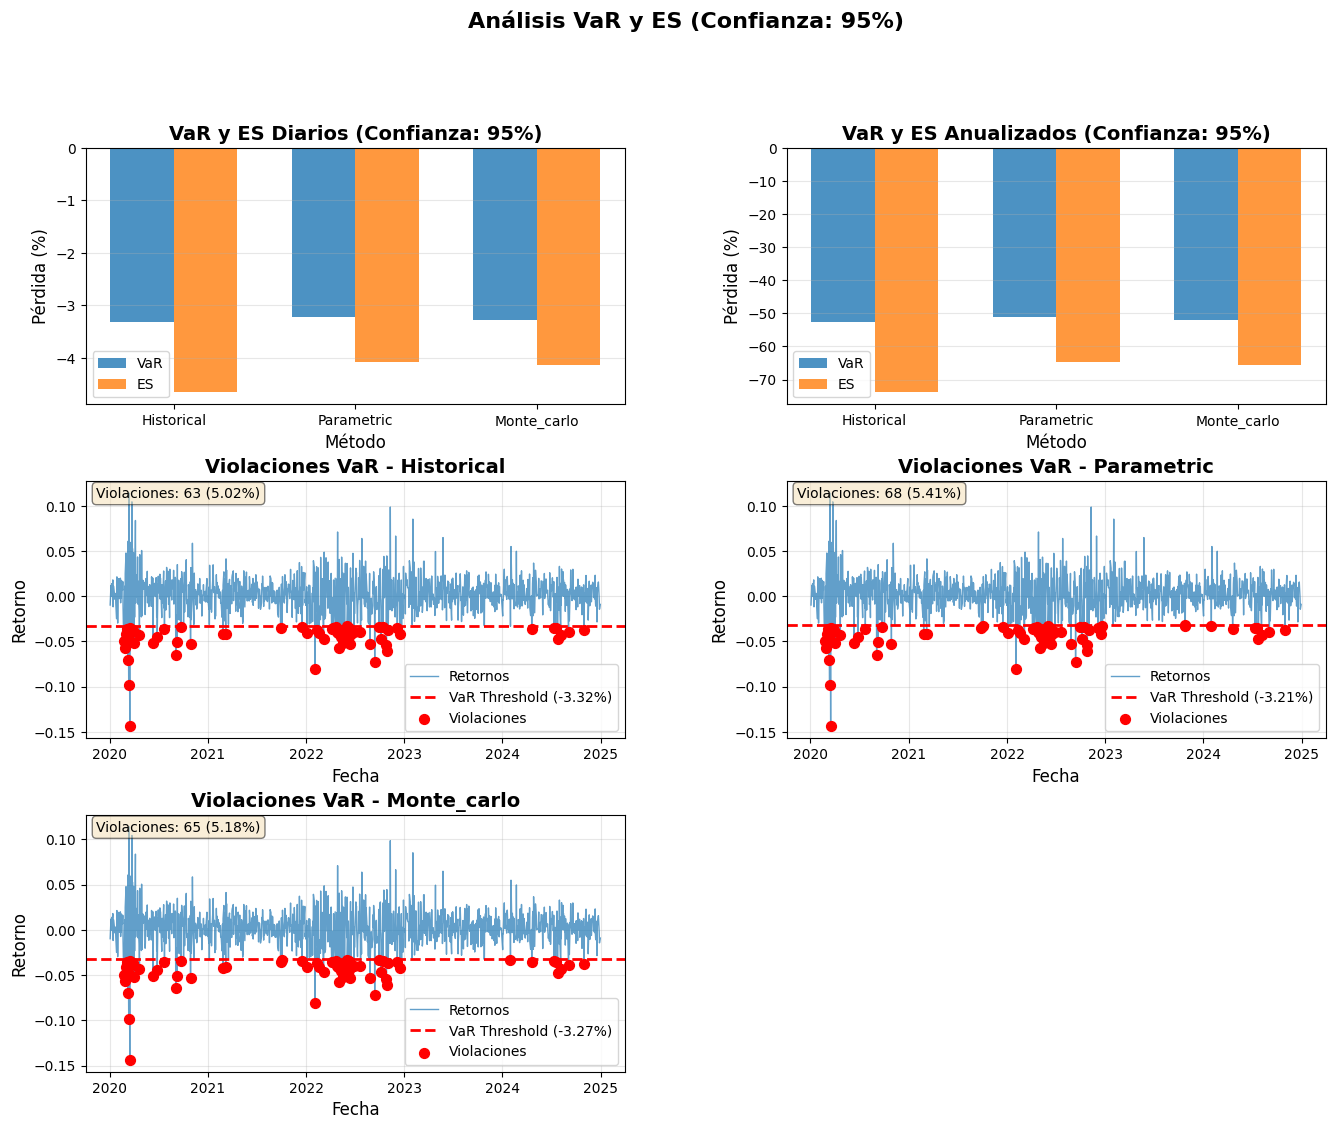

In [ ]:
# 📉 ANÁLISIS DE DRAWDOWN
print("🔍 Analizando drawdowns...\n")

drawdown_result = drawdown_analyzer.analyze_drawdown(
    assets_prices,
    WEIGHTS
)

# Mostrar resultados
drawdown_reporter.print_drawdown_summary(drawdown_result)

# Visualizar
fig = drawdown_viz.plot_drawdown(drawdown_result)
plt.show()

                    ANÁLISIS DE DRAWDOWN                    
MAX DRAWDOWN
  Magnitud:                  -48.53%
  Fecha:                   2022-11-03 00:00:00
  Duración:                355 días
RATIOS DE DRAWDOWN
  Calmar Ratio:               0.781
  Sterling Ratio:             0.818
RETORNO ANUAL
  Retorno Anual:              37.90%
INTERPRETACIÓN
  Nivel de riesgo:         Muy Alto
  Calmar:                  Buena compensación


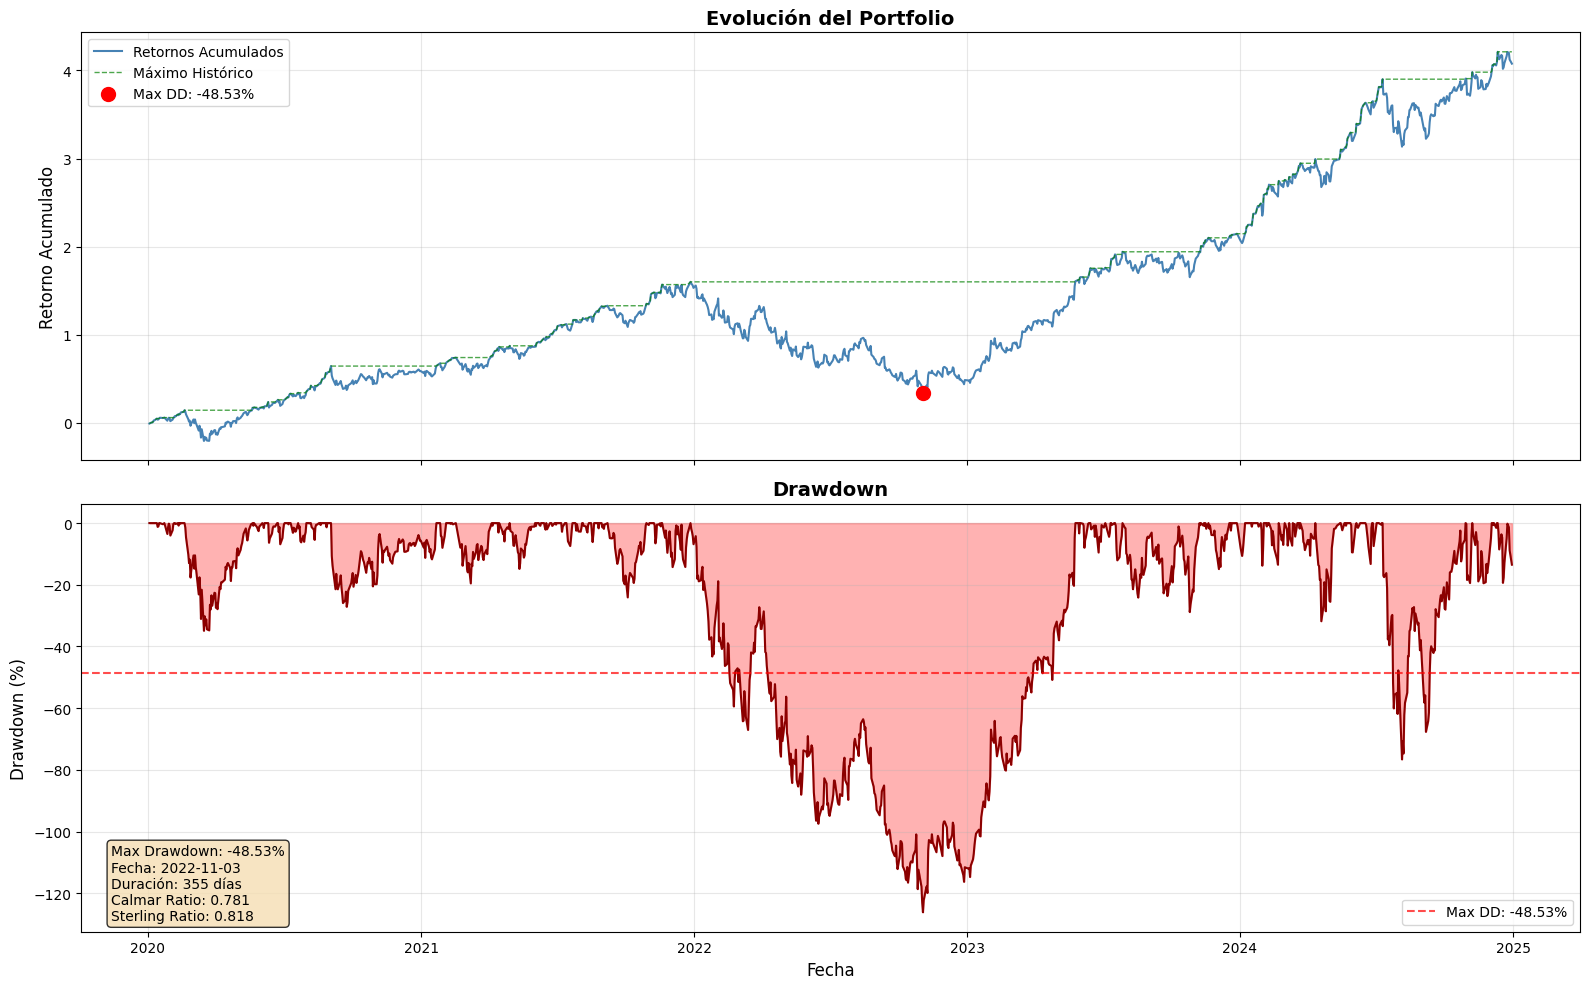

In [ ]:
# 📊 ANÁLISIS DE DISTRIBUCIÓN
print("🔍 Analizando distribución de retornos...\n")

dist_result = dist_analyzer.analyze_distribution(portfolio_returns)

# Mostrar resultados
dist_reporter.print_distribution_summary(dist_result)

# Visualizar
fig = dist_viz.plot_distribution(dist_result)
plt.show()

                  ANÁLISIS DE DISTRIBUCIÓN                  
ASIMETRÍA (Skewness)
  Valor:                     -0.180
  Interpretación:          Aproximadamente simétrica
CURTOSIS (Excess Kurtosis)
  Valor:                      4.771
  Interpretación:          Leptocúrtica (colas pesadas)
                           -> Mayor riesgo de eventos extremos
TEST DE NORMALIDAD (Jarque-Bera)
  Estadístico JB:           1186.11
  p-value:                   0.0000
  Distribución normal:     [NO]


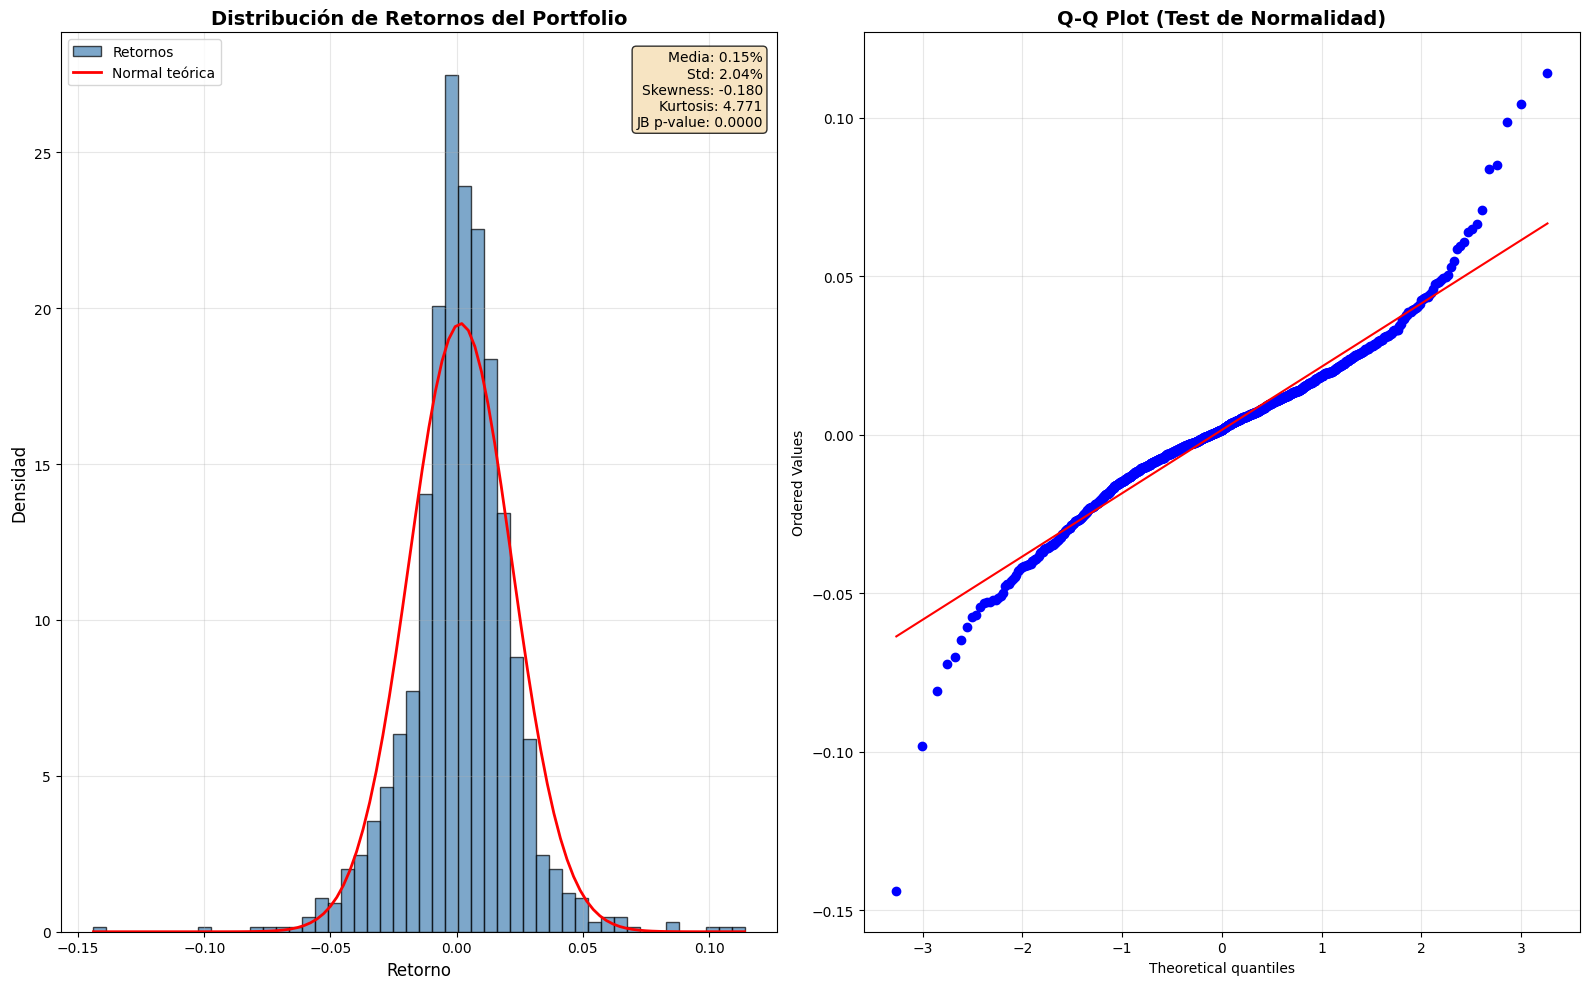

In [ ]:
# 📈 ANÁLISIS VS BENCHMARK
print("🔍 Comparando con benchmark...\n")

benchmark_result = benchmark_analyzer.analyze_vs_benchmark(
    portfolio_returns,
    benchmark_returns,
    RISK_FREE_RATE
)

# Mostrar resultados
benchmark_reporter.print_benchmark_summary(benchmark_result)

# Visualizar
fig = benchmark_viz.plot_vs_benchmark(
    portfolio_returns,
    benchmark_returns,
    benchmark_result
)
plt.show()

In [ ]:
# 🔗 ANÁLISIS DE CORRELACIÓN
print("🔍 Analizando correlaciones...\n")

corr_result = corr_analyzer.analyze_correlation(returns)

# Mostrar resultados
corr_reporter.print_correlation_summary(corr_result)

# Matriz de correlación
print("\n📊 Matriz de Correlación:")
print(corr_result['correlation_matrix'].round(2))

                   ANÁLISIS VS BENCHMARK                    
TRACKING ERROR
  Tracking Error (diario):      1.12%
  Tracking Error (anual):      17.78%
  Interpretación:          Alta desviación del benchmark
INFORMATION RATIO
  Information Ratio:           1.331
  Interpretación:          Excelente - supera al benchmark
BETA
  Beta:                        1.309
  R²:                          0.741
  Correlación:                 0.861
  Interpretación:          Alta sensibilidad (agresivo)
ALPHA (Jensen)
  Alpha (anualizado):          20.66%
  Retorno cartera:             37.90%
  Retorno benchmark:           14.23%
  Retorno esperado (CAPM):     17.24%
  Interpretación:          Excelente - supera expectativas
